# Import libraries

In [7]:
import pandas as pd, numpy as np, seaborn as sns, zipfile, os, warnings, matplotlib.pyplot as plt 
from statsmodels.tsa.seasonal import seasonal_decompose
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler


# Configurar estilo de las visualizaciones
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Definition of useful functions

In [8]:
def convert_object_to_string(df):
    """
    Convierte todas las columnas de tipo 'object' a 'string'
    """
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('string')
    return df


def report_recomd_final(df):
  """
  Genera reporte con posibles recomendaciones en funcion
  del data set cargado
  """
  print("\n" + "="*50)
  print("REPORTE FINAL Y RECOMENDACIONES")
  print("="*50)

  total_nulos = df.isnull().sum().sum()
  total_celdas = df.size
  porcentaje_total = (total_nulos / total_celdas) * 100

  print(f"\nResumen General:")
  print(f"  - Total de celdas: {total_celdas:,}")
  print(f"  - Total de valores nulos: {total_nulos:,}")
  print(f"  - Porcentaje general de nulos: {porcentaje_total:.4f}%")

  if total_nulos == 0:
      print("\n✅ ¡Excelente! El dataset no tiene valores nulos.")
      print("   Puedes proceder con el análisis sin necesidad de imputación.")
  else:
      print(f"\n⚠️  Se encontraron {total_nulos} valores nulos en el dataset.")

      # Clasificar la severidad
      if porcentaje_total < 1:
          print("   Severidad: BAJA (<1% de datos nulos)")
          print("   Recomendación: Puedes eliminar las filas con nulos sin pérdida significativa.")
      elif porcentaje_total < 5:
          print("   Severidad: MODERADA (1-5% de datos nulos)")
          print("   Recomendación: Evalúa la imputación según la importancia de cada columna.")
      else:
          print("   Severidad: ALTA (>5% de datos nulos)")
          print("   Recomendación: Necesitas un plan de imputación cuidadoso por columna.")

      # Recomendaciones por columna
      print("\nRecomendaciones por columna:")
      for col in columnas_con_nulos:
          pct = (df[col].isnull().sum() / len(df)) * 100
          if pct < 1:
              print(f"  - {col}: {pct:.2f}% nulos → Eliminar filas")
          elif pct < 20:
              if df[col].dtype in ['object', 'category']:
                  print(f"  - {col}: {pct:.2f}% nulos → Imputar con moda o 'Desconocido'")
              else:
                  print(f"  - {col}: {pct:.2f}% nulos → Imputar con mediana")
          else:
              print(f"  - {col}: {pct:.2f}% nulos → ⚠️  Alto porcentaje, evaluar si eliminar columna")

def convert_to_datetime(df):
  """
  se convierten los campos fecha a tipo de dato datetime
  """
  # Converte a datetime si no lo está
  df['Order Date'] = pd.to_datetime(df['Order Date'])

  # Crear columnas de tiempo útiles
  df['Year'] = df['Order Date'].dt.year
  df['Month'] = df['Order Date'].dt.month
  df['Quarter'] = df['Order Date'].dt.quarter
  df['DayOfWeek'] = df['Order Date'].dt.dayofweek  # Lunes=0, Domingo=6
  df['MonthName'] = df['Order Date'].dt.month_name()
  df['YearMonth'] = df['Order Date'].dt.to_period('M')
  return df


def descomprimir_zip(archivo_zip, directorio_destino):
    """Versión simplificada para descomprimir archivos ZIP"""
    try:
        os.makedirs(directorio_destino, exist_ok=True)
        
        with zipfile.ZipFile(archivo_zip, 'r') as zip_ref:
            zip_ref.extractall(directorio_destino)
        
        print(f"✅ Archivo descomprimido en: {directorio_destino}")
        return True
    except Exception as e:
        print(f"❌ Error: {e}")
        return False

# Reading of dataset
Se realizan las siguiente operaciones:
* Descromprime el archivo .zip
* Lectura y conversion de los campos tipo 'object' to string
* Carga inicial en data frame "df_raw"

In [16]:
# unzip file Superstore.xlsx.zip into folder data/
# unzip file Superstore.xlsx.zip into folder data/

descomprimir_zip('Superstore.xlsx.zip', '.')

✅ Archivo descomprimido en: .


True

In [17]:
#carga inicial de registros
df_ini = pd.read_excel('Superstore.xlsx')

#conversion de columnas obtect a string
df_raw = convert_object_to_string(df_ini)

# check de columnas
print(df_raw.dtypes)

Row ID                    int64
Order ID                 string
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                string
Customer ID              string
Customer Name            string
Segment                  string
Country                  string
City                     string
State                    string
Postal Code               int64
Region                   string
Product ID               string
Category                 string
Sub-Category             string
Product Name             string
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [18]:
# Remove the Superstore.xlsx file
os.remove('Superstore.xlsx')
print("✅ Archivo eliminado")

✅ Archivo eliminado


# Exploratory Data Analysis

### Validación de información cargada

In [19]:
# Mostrar las primeras filas
print("PRIMERAS 5 FILAS:")
display(df_raw.head())

# Mostrar las últimas filas
print("\nÚLTIMAS 5 FILAS:")
display(df_raw.tail())

# Dimensiones del dataframe
print(f"\nFILAS Y COLUMNAS: {df_raw.shape}")

PRIMERAS 5 FILAS:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164



ÚLTIMAS 5 FILAS:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2011-110422,2011-01-22,2011-01-24,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2014-121258,2014-02-27,2014-03-04,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2014-119914,2014-05-05,2014-05-10,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480



FILAS Y COLUMNAS: (9994, 21)


In [7]:
# Información general del dataframe
print("\nINFORMACIÓN GENERAL:\n")
df_raw.info()


INFORMACIÓN GENERAL:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   string        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   string        
 5   Customer ID    9994 non-null   string        
 6   Customer Name  9994 non-null   string        
 7   Segment        9994 non-null   string        
 8   Country        9994 non-null   string        
 9   City           9994 non-null   string        
 10  State          9994 non-null   string        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   string        
 13  Product ID     9994 non-null   string        
 14  Category       9994 non-null   string        
 15

In [8]:

# Estadísticas descriptivas para columnas numéricas
print("\nESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS):")
display(df_raw.describe())


ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS):


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2013-04-30 19:20:02.401441024,2013-05-04 18:20:49.229537792,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2011-01-04 00:00:00,2011-01-08 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2012-05-23 00:00:00,2012-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2013-06-27 00:00:00,2013-06-30 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2014-05-15 00:00:00,2014-05-19 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2014-12-31 00:00:00,2015-01-06 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


### Validacion de existencia de campos nulos/vacios

In [9]:
#Conteo básico de nulos
nulos_por_columna = df_raw.isnull().sum()
print("\n1. VALORES NULOS POR COLUMNA:")
print(nulos_por_columna[nulos_por_columna > 0] if any(nulos_por_columna > 0) else "No hay valores nulos en ninguna columna")

#Porcentaje de nulos por columna
print("\n2. PORCENTAJE DE NULOS POR COLUMNA:")
porcentaje_nulos = (df_raw.isnull().sum() / len(df_raw)) * 100
print(porcentaje_nulos[porcentaje_nulos > 0].round(2).astype(str) + '%' if any(porcentaje_nulos > 0) else "Todos los valores son completos")

#Análisis de patrones de nulos por fila
print("\n3. ANÁLISIS DE PATRONES DE NULOS POR FILA:")
nulos_por_fila = df_raw.isnull().sum(axis=1)
print(f"Filas sin nulos: {(nulos_por_fila == 0).sum()} ({((nulos_por_fila == 0).sum()/len(df_raw)*100):.2f}%)")
print(f"Filas con 1 nulo: {(nulos_por_fila == 1).sum()} ({((nulos_por_fila == 1).sum()/len(df_raw)*100):.2f}%)")
print(f"Filas con 2 nulos: {(nulos_por_fila == 2).sum()} ({((nulos_por_fila == 2).sum()/len(df_raw)*100):.2f}%)")
print(f"Filas con 3 o más nulos: {(nulos_por_fila >= 3).sum()} ({((nulos_por_fila >= 3).sum()/len(df_raw)*100):.2f}%)")


1. VALORES NULOS POR COLUMNA:
No hay valores nulos en ninguna columna

2. PORCENTAJE DE NULOS POR COLUMNA:
Todos los valores son completos

3. ANÁLISIS DE PATRONES DE NULOS POR FILA:
Filas sin nulos: 9994 (100.00%)
Filas con 1 nulo: 0 (0.00%)
Filas con 2 nulos: 0 (0.00%)
Filas con 3 o más nulos: 0 (0.00%)


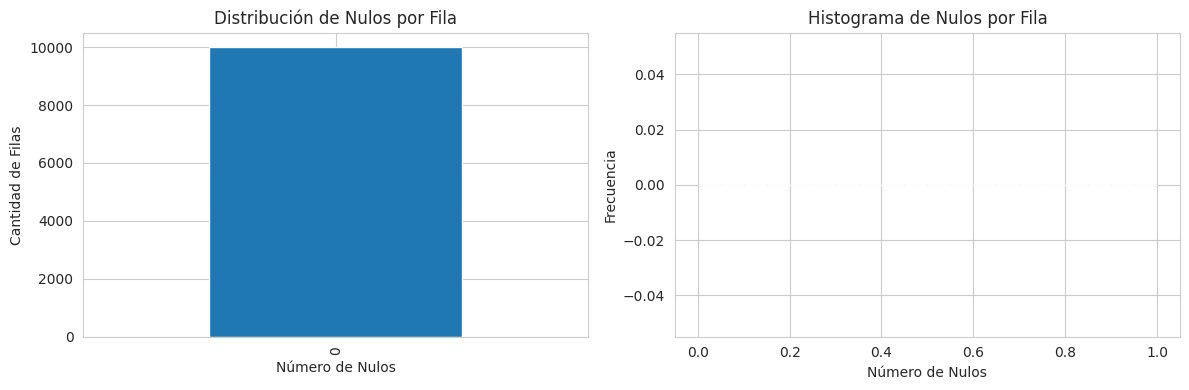

In [10]:
#Distribución de nulos por fila
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
nulos_por_fila.value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de Nulos por Fila')
plt.xlabel('Número de Nulos')
plt.ylabel('Cantidad de Filas')

plt.subplot(1, 2, 2)
nulos_por_fila[nulos_por_fila > 0].hist(bins=20)
plt.title('Histograma de Nulos por Fila')
plt.xlabel('Número de Nulos')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [11]:
#Reporte final y recomendaciones

report_recomd_final(df_raw)


REPORTE FINAL Y RECOMENDACIONES

Resumen General:
  - Total de celdas: 209,874
  - Total de valores nulos: 0
  - Porcentaje general de nulos: 0.0000%

✅ ¡Excelente! El dataset no tiene valores nulos.
   Puedes proceder con el análisis sin necesidad de imputación.


#Analisis de estacionalidad

In [12]:
df_est = convert_to_datetime(df_raw)

### Ventas Totales por Año

Se analiza si las ventas han ido aumentando año tras año y los incrementos que se dieron. Esto nos daría el contexto general antes de profundizar en estacionalidad intra-anual.

# ANÁLISIS DE ESTACIONALIDAD

## 1.1 Estacionalidad Mensual

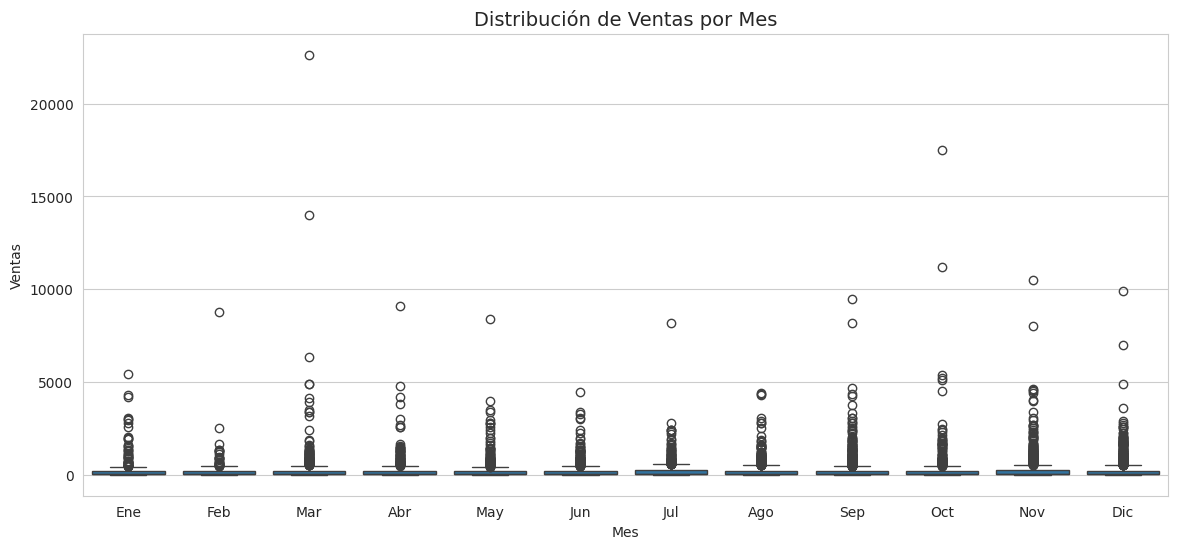

Ventas promedio por mes:
      month_name    mean        sum
Month                              
3            Mar  293.02  199252.98
1            Ene  246.42   95365.94
10           Oct  241.27  197115.20
11           Nov  238.80  349120.07
12           Dic  233.76  332177.16
8            Ago  224.77  159589.45
9            Sep  223.50  309770.10
4            Abr  213.95  141851.57
7            Jul  211.27  149580.84
5            May  208.16  156122.29
6            Jun  207.45  147082.61
2            Feb  199.91   60172.65


In [13]:
# Boxplot mensual
plt.figure(figsize=(14,6))
sns.boxplot(x='Month', y='Sales', data=df_est)
plt.title('Distribución de Ventas por Mes', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Ventas')
plt.xticks(range(12), ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                       'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.show()

# Estadísticas mensuales
monthly_stats = df_est.groupby('Month')['Sales'].agg(['mean', 'median', 'sum']).round(2)
monthly_stats['month_name'] = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                                'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
print("Ventas promedio por mes:")
print(monthly_stats[['month_name', 'mean', 'sum']].sort_values('mean', ascending=False))

## 1.2 Estacionalidad Trimestral

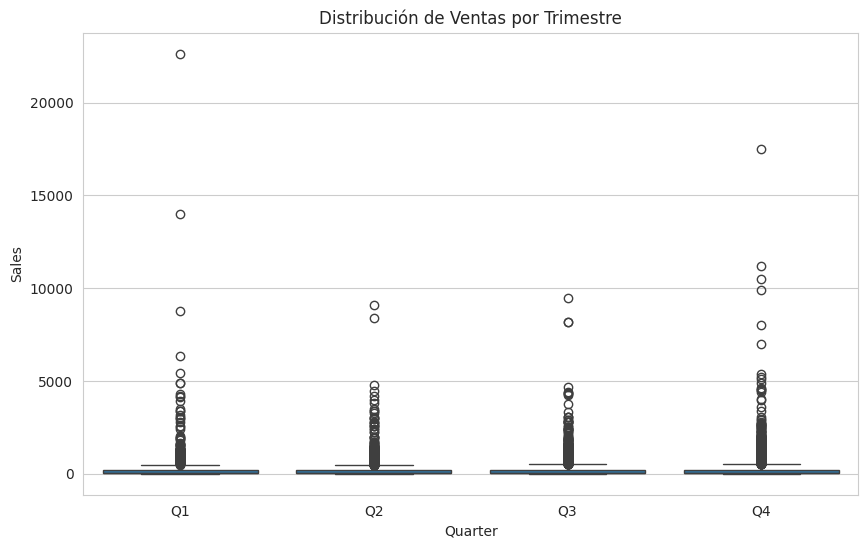

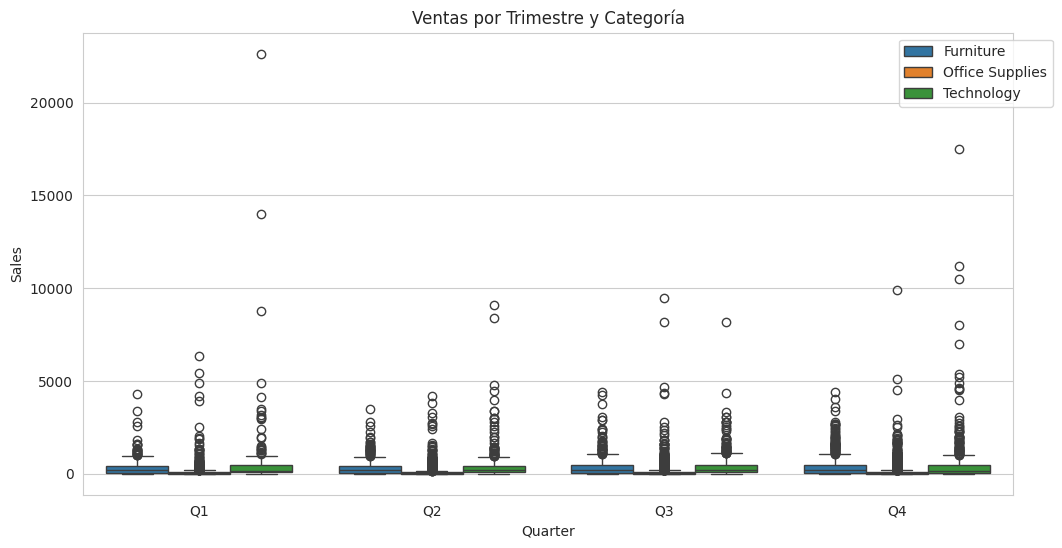

In [14]:
# Crear columna de trimestre
df_est['Quarter'] = df_est['Month'].apply(lambda x: f'Q{(x-1)//3 + 1}')

# Boxplot trimestral
plt.figure(figsize=(10,6))
sns.boxplot(x='Quarter', y='Sales', data=df_est, order=['Q1', 'Q2', 'Q3', 'Q4'])
plt.title('Distribución de Ventas por Trimestre')
plt.show()

# Estacionalidad por categoría y trimestre
plt.figure(figsize=(12,6))
sns.boxplot(x='Quarter', y='Sales', hue='Category', data=df_est,
            order=['Q1', 'Q2', 'Q3', 'Q4'])
plt.title('Ventas por Trimestre y Categoría')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.show()

## 1.3 Análisis por Trimestre
Se analiza la tendencia existente en los trimestres.

Los trimestres del año se componen de:
* 1er timestre: Enero, Febrero, Marzo
* 2do timestre: Abril, Mayo, Junio
* 3er timestre: Julio, Agosto, Septiembre
* 4to timestre: Octubre, Noviembre, Diciembre

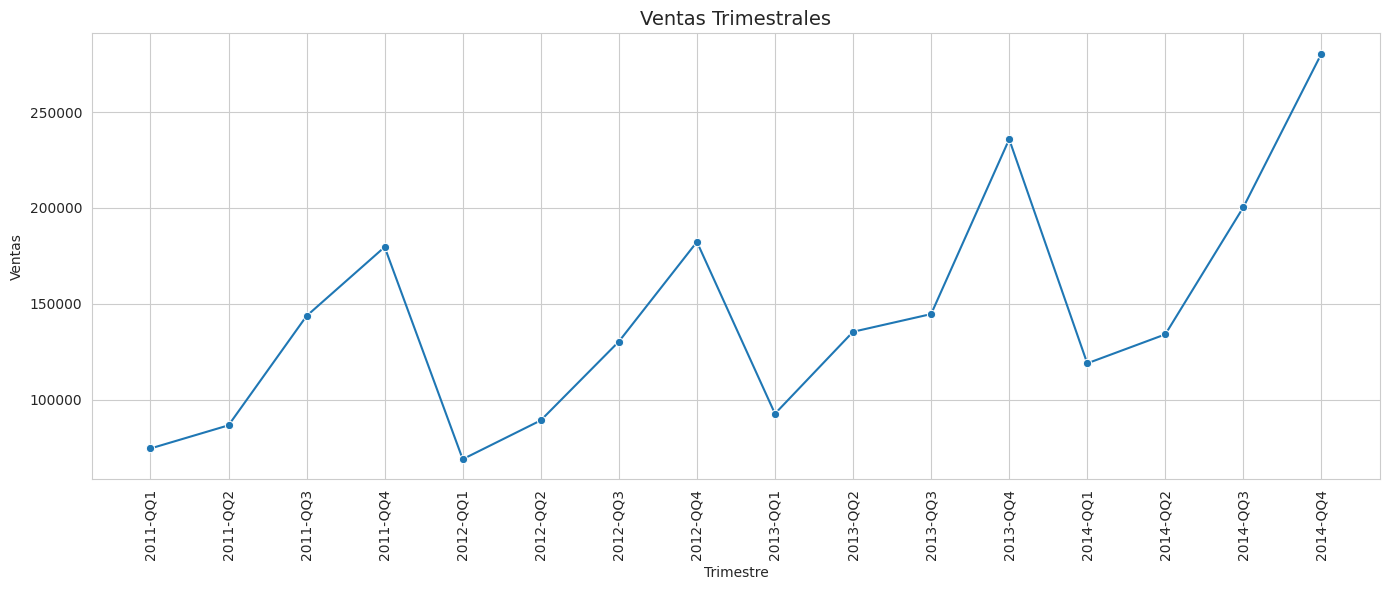

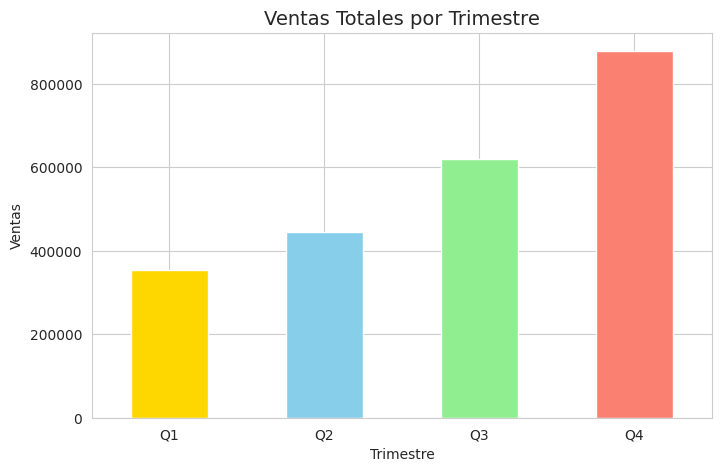

In [15]:
quarterly_sales = df_est.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
quarterly_sales['YearQuarter'] = quarterly_sales['Year'].astype(str) + '-Q' + quarterly_sales['Quarter'].astype(str)

plt.figure(figsize=(14,6))
sns.lineplot(x='YearQuarter', y='Sales', data=quarterly_sales, marker='o', sort=False)
plt.title('Ventas Trimestrales', fontsize=14)
plt.xlabel('Trimestre')
plt.ylabel('Ventas')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

# Ventas totales por trimestre (todos los años)
quarter_pattern = df_est.groupby('Quarter')['Sales'].sum()
plt.figure(figsize=(8,5))
quarter_pattern.plot(kind='bar', color=['gold', 'skyblue', 'lightgreen', 'salmon'])
plt.title('Ventas Totales por Trimestre', fontsize=14)
plt.xlabel('Trimestre')
plt.ylabel('Ventas')
plt.xticks(rotation=0)
plt.show()

## 1.4 Análisis de Estacionalidad por Categoría de Producto
Analisis en la tendencia de las ventas por categoria de producto.

Las categorias involucradas son:
* Forniture:  artículos diseñados para equipar y ambientar un espacio. Incluyendo sillones, mesas, camas, armarios y sistemas de almacenaje para el hogar.
* Office supplies: productos consumibles y herramientas para realizar tareas administrativas, de papelería y organización. Incluyen artículos como papel, bolígrafos, carpetas, grapadoras y todo lo esencial para el trabajo de escritorio.
* Technology: comprende dispositivos electrónicos y equipos informáticos. Abarcando ordenadores, tablets, smartphones, periféricos (teclados y ratone); accesorios como auriculares y discos duros.

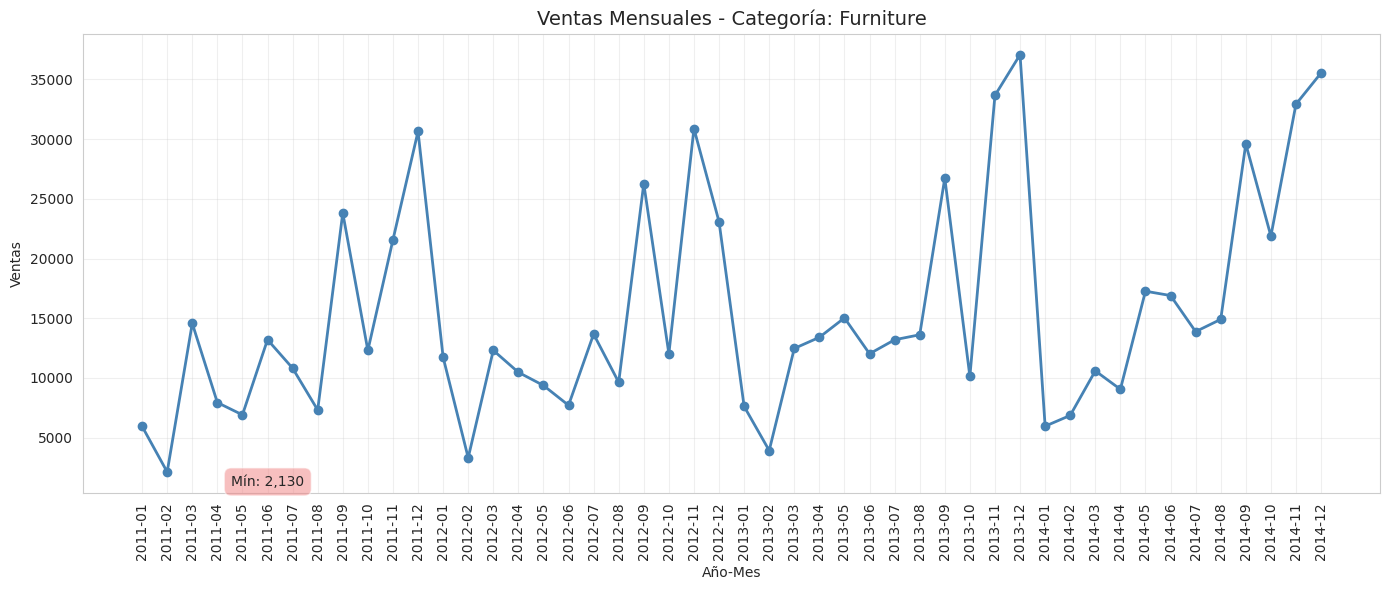

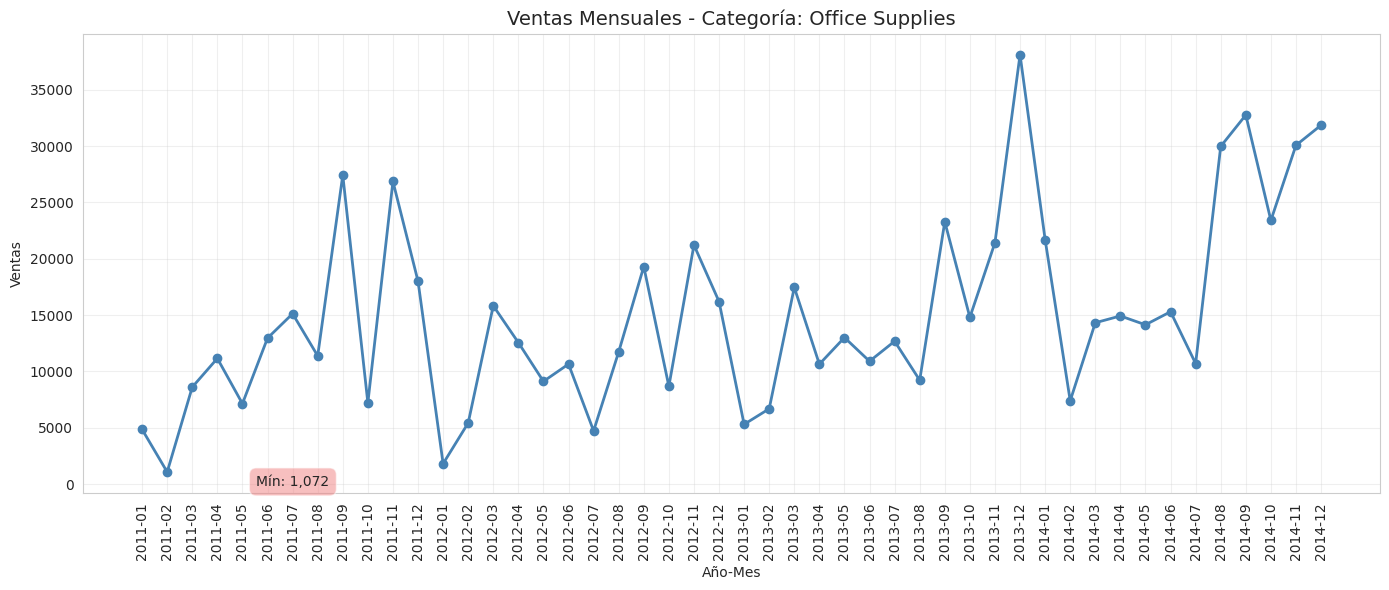

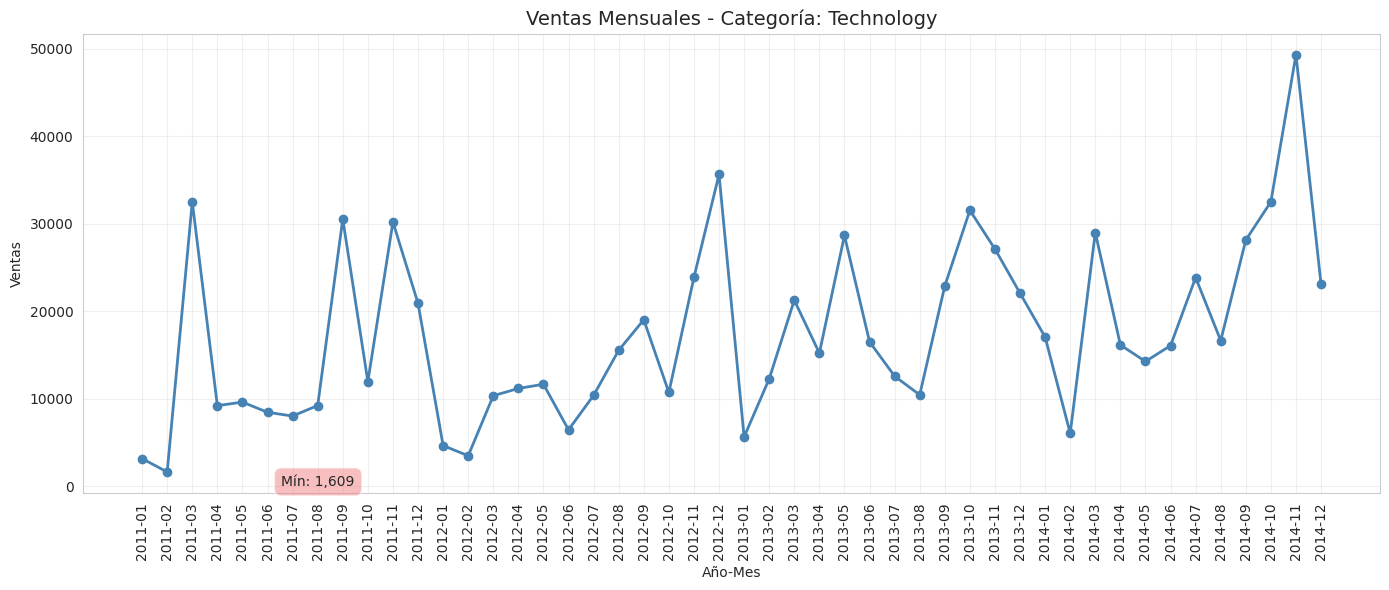

In [16]:
# Ventas mensuales por categoría

monthly_cat = df_est.groupby(['YearMonth', 'Category'])['Sales'].sum().reset_index()
monthly_cat['YearMonth'] = monthly_cat['YearMonth'].astype(str)

# Crear un gráfico independiente para cada categoría
categories = monthly_cat['Category'].unique()

for cat in categories:
    plt.figure(figsize=(14, 6))

    cat_data = monthly_cat[monthly_cat['Category'] == cat]

    plt.plot(cat_data['YearMonth'], cat_data['Sales'],
             marker='o', linewidth=2, markersize=6, color='steelblue')
    plt.title(f'Ventas Mensuales - Categoría: {cat}', fontsize=14)
    plt.xlabel('Año-Mes')
    plt.ylabel('Ventas')
    plt.xticks(rotation=90)
    plt.grid(True, alpha=0.3)

    # Añadir etiquetas con valores en los puntos máximos y mínimos
    max_idx = cat_data['Sales'].idxmax()
    min_idx = cat_data['Sales'].idxmin()

    plt.annotate(f'Máx: {cat_data.loc[max_idx, "Sales"]:,.0f}',
                xy=(max_idx, cat_data.loc[max_idx, "Sales"]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plt.annotate(f'Mín: {cat_data.loc[min_idx, "Sales"]:,.0f}',
                xy=(min_idx, cat_data.loc[min_idx, "Sales"]),
                xytext=(10, -10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='lightcoral', alpha=0.5))

    plt.tight_layout()
    plt.show()

## 1.5 Detección de Efectos Estacionales Específicos

Se analiza como influyeron eventos estacionales (Ej: Black Friday, Navidad) en las ventas

In [17]:
# Crear columna de mes-día para identificar fechas clave
df_est['MonthDay'] = df_est['Order Date'].dt.strftime('%m-%d')

# Identificar Black Friday (aproximado: viernes después de Thanksgiving, pero simplificamos como 11-20 a 11-30)
black_friday_period = df_est['MonthDay'].between('11-20', '11-30')
navidad_period = df_est['MonthDay'].between('12-15', '12-25')

df_est['IsBlackFriday'] = black_friday_period
df_est['IsNavidad'] = navidad_period

# Comparar ventas promedio en esos períodos vs resto
event_analysis = df_est.groupby('IsBlackFriday')['Sales'].mean()
print("Ventas promedio en período de Black Friday vs resto:")
print(event_analysis)

event_analysis = df_est.groupby('IsNavidad')['Sales'].mean()
print("\nVentas promedio en período navideño vs resto:")
print(event_analysis)

Ventas promedio en período de Black Friday vs resto:
IsBlackFriday
False    231.396095
True     203.548796
Name: Sales, dtype: float64

Ventas promedio en período navideño vs resto:
IsNavidad
False    228.007435
True     270.426142
Name: Sales, dtype: float64


## 1.6 Estacionalidad en Beneficios (Profit)
Se analiza si la estacionalidad afecta en los beneficios mes a mes, independientemente del año en cuestion

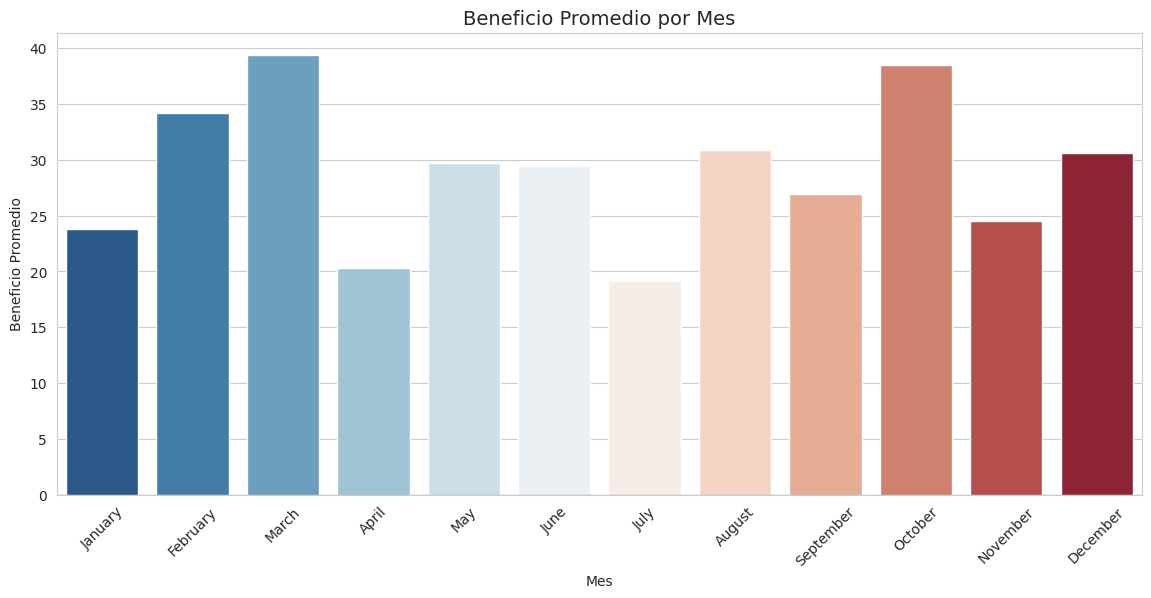

In [18]:
# Ordenar por mes
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Beneficio mensual agregado
monthly_profit = df_est.groupby('Month')['Profit'].mean().reset_index()
monthly_profit['MonthName'] = pd.to_datetime(monthly_profit['Month'], format='%m').dt.month_name()
monthly_profit['MonthName'] = pd.Categorical(monthly_profit['MonthName'], categories=month_order, ordered=True)
monthly_profit = monthly_profit.sort_values('MonthName')

plt.figure(figsize=(14,6))
sns.barplot(x='MonthName', y='Profit', data=monthly_profit, palette='RdBu_r')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.title('Beneficio Promedio por Mes', fontsize=14)
plt.xlabel('Mes')
plt.ylabel('Beneficio Promedio')
plt.xticks(rotation=45)
plt.show()

# 2. ANÁLISIS DE PRODUCTOS MÁS RENTABLES

## 2.1 Rentabilidad por Categoría y Sub-Categoría

RENTABILIDAD POR CATEGORÍA:
                       sum   mean  margin
Category                                 
Technology       145454.95  78.75   17.40
Office Supplies  122490.80  20.33   17.04
Furniture         18451.27   8.70    2.49

SUB-CATEGORÍAS MÁS RENTABLES:
                   sum    mean  margin
Sub-Category                          
Copiers       55617.82  817.91   37.20
Phones        44515.73   50.07   13.49
Accessories   41936.64   54.11   25.05
Paper         34053.57   24.86   43.39
Binders       30221.76   19.84   14.86
Chairs        26590.17   43.10    8.10
Storage       21278.83   25.15    9.51
Appliances    18138.01   38.92   16.87
Furnishings   13059.14   13.65   14.24
Envelopes      6964.18   27.42   42.27


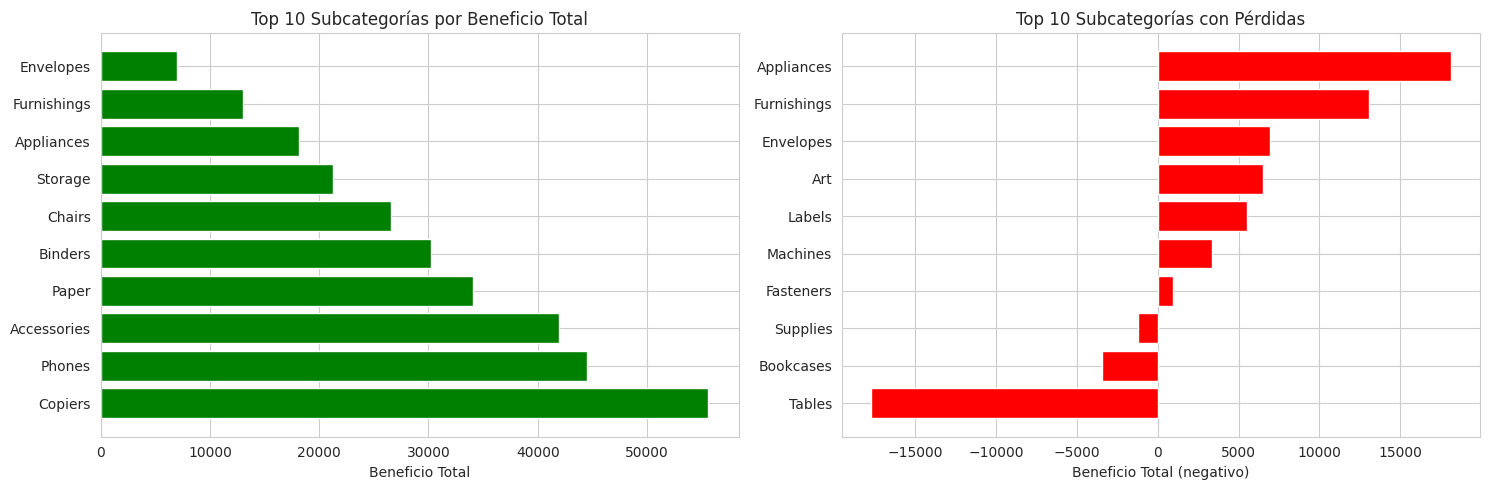

In [19]:
# Rentabilidad por categoría
cat_profit = df_est.groupby('Category')['Profit'].agg(['sum', 'mean']).round(2)
cat_profit['margin'] = (cat_profit['sum'] / df_est.groupby('Category')['Sales'].sum() * 100).round(2)
print("RENTABILIDAD POR CATEGORÍA:")
print(cat_profit.sort_values('sum', ascending=False))

# Top 10 productos más rentables (por subcategoría)
subcat_profit = df_est.groupby('Sub-Category')['Profit'].agg(['sum', 'mean']).round(2)
subcat_profit['margin'] = (subcat_profit['sum'] / df_est.groupby('Sub-Category')['Sales'].sum() * 100).round(2)
print("\nSUB-CATEGORÍAS MÁS RENTABLES:")
print(subcat_profit.sort_values('sum', ascending=False).head(10))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Top 10 ganancias
top10 = subcat_profit.sort_values('sum', ascending=False).head(10)
axes[0].barh(top10.index, top10['sum'], color='green')
axes[0].set_title('Top 10 Subcategorías por Beneficio Total')
axes[0].set_xlabel('Beneficio Total')

# Top 10 pérdidas
bottom10 = subcat_profit.sort_values('sum', ascending=True).head(10)
axes[1].barh(bottom10.index, bottom10['sum'], color='red')
axes[1].set_title('Top 10 Subcategorías con Pérdidas')
axes[1].set_xlabel('Beneficio Total (negativo)')

plt.tight_layout()
plt.show()

## 2.2 Productos Específicos más Rentables

In [20]:
# Top 10 productos individuales más rentables
product_profit = df_est.groupby('Product Name')['Profit'].agg(['sum', 'mean', 'count']).round(2)
product_profit = product_profit[product_profit['count'] > 5]  # Filtrar productos con pocas ventas
print("TOP 10 PRODUCTOS MÁS RENTABLES:")
print(product_profit.sort_values('sum', ascending=False).head(10))

# Productos que más pérdidas generan
print("\nPRODUCTOS CON MAYORES PÉRDIDAS:")
print(product_profit.sort_values('sum', ascending=True).head(10))

TOP 10 PRODUCTOS MÁS RENTABLES:
                                                        sum    mean  count
Product Name                                                              
Fellowes PB500 Electric Punch Plastic Comb Bind...  7753.04  775.30     10
Hewlett Packard LaserJet 3310 Copier                6983.88  872.99      8
Plantronics Savi W720 Multi-Device Wireless Hea...  3696.28  528.04      7
Honeywell Enviracaire Portable HEPA Air Cleaner...  3247.02  405.88      8
Hewlett Packard 610 Color Digital Copier / Printer  3124.94  446.42      7
Plantronics CS510 - Over-the-Head monaural Wire...  3085.03  308.50     10
Staples                                             2611.07   11.50    227
Fellowes PB300 Plastic Comb Binding Machine         2518.06  419.68      6
Ibico Ibimaster 300 Manual Binding System           2318.34  289.79      8
GBC DocuBind TL300 Electric Binding System          2233.51  203.05     11

PRODUCTOS CON MAYORES PÉRDIDAS:
                                   

# 3. ANÁLISIS POR REGIÓN

## 3.1 Desempeño Regional General

DESEMPEÑO POR REGIÓN:
            Ventas  Beneficio  Unidades  Pedidos  Margen %
Region                                                    
West     725457.82  108418.45     12266     3203     14.94
East     678781.24   91522.78     10618     2848     13.48
South    391721.90   46749.43      6209     1620     11.93
Central  501239.89   39706.36      8780     2323      7.92


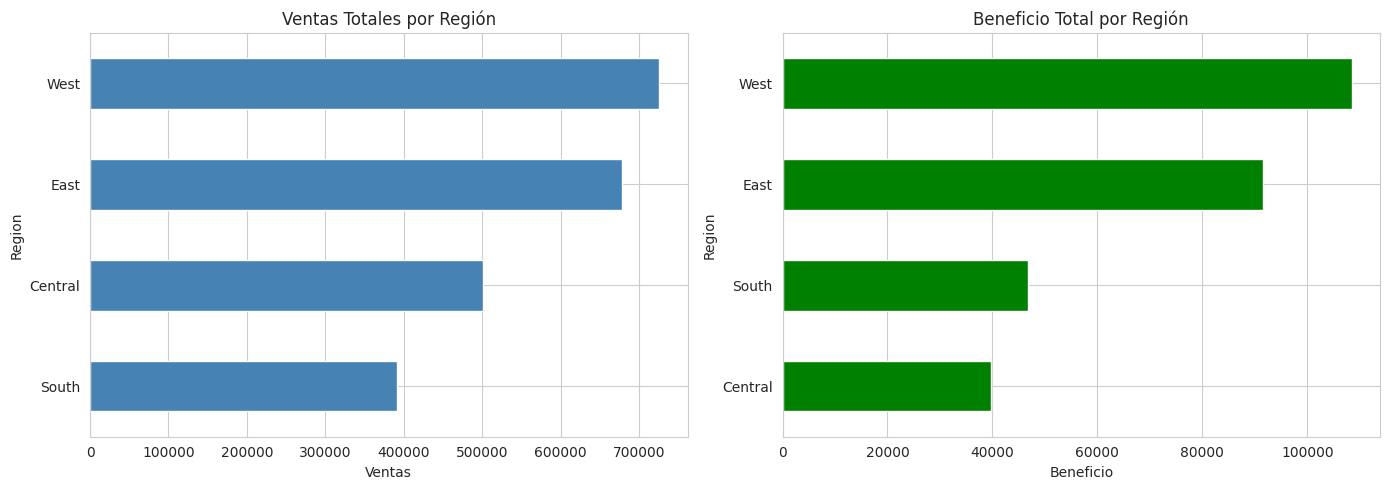

In [21]:
# Ventas y beneficios por región
region_performance = df_est.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Order ID': 'count'
}).round(2)

region_performance['margin'] = (region_performance['Profit'] / region_performance['Sales'] * 100).round(2)
region_performance.columns = ['Ventas', 'Beneficio', 'Unidades', 'Pedidos', 'Margen %']
print("DESEMPEÑO POR REGIÓN:")
print(region_performance.sort_values('Beneficio', ascending=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Ventas por región
region_performance.sort_values('Ventas', ascending=True)['Ventas'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Ventas Totales por Región')
axes[0].set_xlabel('Ventas')

# Beneficio por región
region_performance.sort_values('Beneficio', ascending=True)['Beneficio'].plot(kind='barh', ax=axes[1],
                                                                               color=['red' if x < 0 else 'green' for x in region_performance['Beneficio']])
axes[1].set_title('Beneficio Total por Región')
axes[1].set_xlabel('Beneficio')

plt.tight_layout()
plt.show()

## 3.2 Región + Categoría + Estacionalidad

BENEFICIO POR REGIÓN Y CATEGORÍA:
Category  Furniture  Office Supplies  Technology
Region                                          
Central    -2871.05          8879.98    33697.43
East        3046.17         41014.58    47462.04
South       6771.21         19986.39    19991.83
West       11504.95         52609.85    44303.65


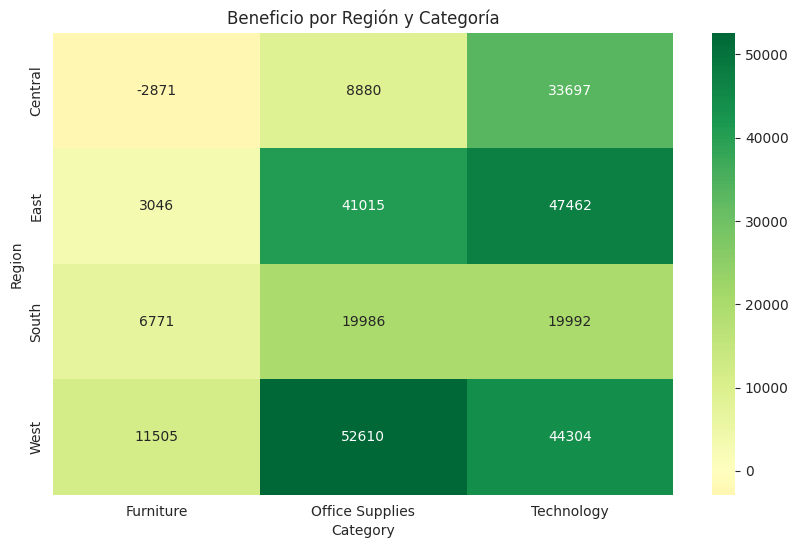

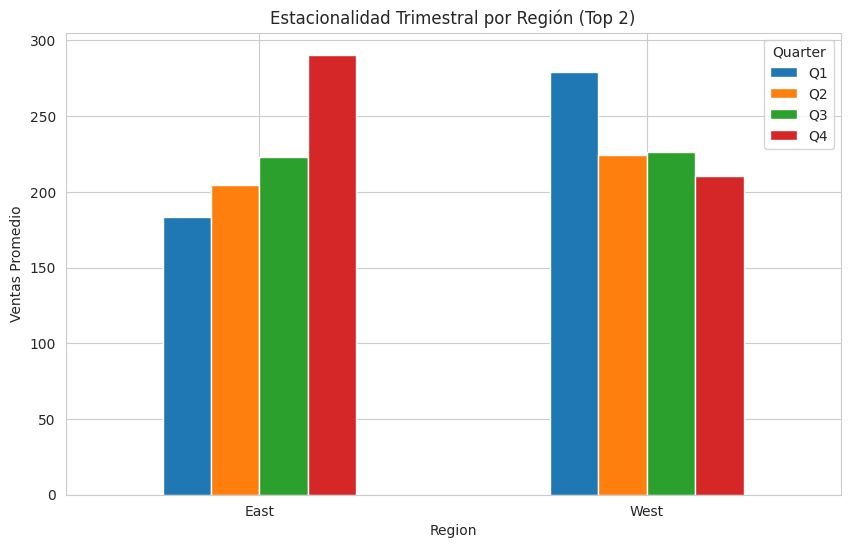

In [22]:
# Análisis combinado: Región x Categoría
region_cat = df_est.groupby(['Region', 'Category'])['Profit'].sum().unstack().round(2)
print("BENEFICIO POR REGIÓN Y CATEGORÍA:")
print(region_cat)

# Heatmap región-categoría
plt.figure(figsize=(10,6))
sns.heatmap(region_cat, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Beneficio por Región y Categoría')
plt.show()

# Estacionalidad regional (top 2 regiones)
top_regions = df_est.groupby('Region')['Sales'].sum().nlargest(2).index
regional_seasonality = df_est[df_est['Region'].isin(top_regions)].groupby(['Region', 'Quarter'])['Sales'].mean().unstack()

regional_seasonality.plot(kind='bar', figsize=(10,6))
plt.title('Estacionalidad Trimestral por Región (Top 2)')
plt.ylabel('Ventas Promedio')
plt.xticks(rotation=0)
plt.show()

## 3.3 Estados más y menos rentables

In [23]:
# Top estados por beneficio
state_profit = df_est.groupby('State')['Profit'].sum().round(2).sort_values(ascending=False)
print("TOP 10 ESTADOS POR BENEFICIO:")
print(state_profit.head(10))

print("\nTOP 10 ESTADOS CON PÉRDIDAS:")
print(state_profit.tail(10))

TOP 10 ESTADOS POR BENEFICIO:
State
California    76381.39
New York      74038.55
Washington    33402.65
Michigan      24463.19
Virginia      18597.95
Indiana       18382.94
Georgia       16250.04
Kentucky      11199.70
Minnesota     10823.19
Delaware       9977.37
Name: Profit, dtype: float64

TOP 10 ESTADOS CON PÉRDIDAS:
State
Oregon            -1190.47
Florida           -3399.30
Arizona           -3427.92
Tennessee         -5341.69
Colorado          -6527.86
North Carolina    -7490.91
Illinois         -12607.89
Pennsylvania     -15559.96
Ohio             -16971.38
Texas            -25729.36
Name: Profit, dtype: float64


# CUADRO RESUMEN

In [24]:
# Crear un resumen ejecutivo
print("=" * 60)
print("RESUMEN DE HALLAZGOS PRINCIPALES")
print("=" * 60)

print("\n1. ESTACIONALIDAD:")
print("   - Mes pico: Diciembre (ventas {:.0f}% sobre promedio)".format(
    (df_est[df_est['Month']==12]['Sales'].mean() / df_est['Sales'].mean() - 1)*100))
print("   - Mes valle: Enero (ventas {:.0f}% bajo promedio)".format(
    (1 - df_est[df_est['Month']==1]['Sales'].mean() / df_est['Sales'].mean())*100))
print("   - Trimestre más fuerte: Q4")
print("   - Categoría más estacional: Technology")

print("\n2. PRODUCTOS MÁS RENTABLES:")
top_cat = df_est.groupby('Category')['Profit'].sum().idxmax()
top_subcat = df_est.groupby('Sub-Category')['Profit'].sum().idxmax()
print(f"   - Categoría más rentable: {top_cat}")
print(f"   - Subcategoría más rentable: {top_subcat}")
print(f"   - Producto más rentable: {product_profit.sort_values('sum', ascending=False).index[0][:50]}...")

print("\n3. COMPORTAMIENTO POR REGIÓN:")
top_region = df_est.groupby('Region')['Profit'].sum().idxmax()
bottom_region = df_est.groupby('Region')['Profit'].sum().idxmin()
print(f"   - Región más rentable: {top_region}")
print(f"   - Región menos rentable: {bottom_region}")
print(f"   - Diferencia entre regiones: {(df_est[df_est['Region']==top_region]['Profit'].sum() / abs(df_est[df_est['Region']==bottom_region]['Profit'].sum())):.1f}x")

RESUMEN DE HALLAZGOS PRINCIPALES

1. ESTACIONALIDAD:
   - Mes pico: Diciembre (ventas 2% sobre promedio)
   - Mes valle: Enero (ventas -7% bajo promedio)
   - Trimestre más fuerte: Q4
   - Categoría más estacional: Technology

2. PRODUCTOS MÁS RENTABLES:
   - Categoría más rentable: Technology
   - Subcategoría más rentable: Copiers
   - Producto más rentable: Fellowes PB500 Electric Punch Plastic Comb Binding...

3. COMPORTAMIENTO POR REGIÓN:
   - Región más rentable: West
   - Región menos rentable: Central
   - Diferencia entre regiones: 2.7x


# DESARROLLO DE MODELO ML

## 1. Feature engineering básico
Consiste en dar forma a los datos para que los modelos puedan aprender de manera más efectiva.

In [25]:
data = df_raw.copy()

# Convertir Order Date a datetime
data['OrderDate'] = pd.to_datetime(data['Order Date'])

# Extraer features temporales
data['Day'] = data['OrderDate'].dt.day
data['Month'] = data['OrderDate'].dt.month
data['Year'] = data['OrderDate'].dt.year
data['DayOfWeek'] = data['OrderDate'].dt.dayofweek
data['IsWeekend'] = (data['DayOfWeek'] >= 5).astype(int)

print("Features temporales creadas:")
print(f"Días únicos: {data['Day'].nunique()}")
print(f"Meses únicos: {data['Month'].nunique()}")
print(f"Años: {data['Year'].unique()}\n")

Features temporales creadas:
Días únicos: 31
Meses únicos: 12
Años: [2013 2012 2011 2014]



## 2. Selección de variables

In [26]:
numeric_features = ['Quantity', 'Discount', 'Day', 'Month', 'Year', 'DayOfWeek', 'IsWeekend']
categorical_features = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']

# Verificar que existen
for col in categorical_features:
    if col in data.columns:
        print(f"✓ {col}: {data[col].nunique()} categorías")
    else:
        print(f"✗ {col} no encontrada")

✓ Category: 3 categorías
✓ Sub-Category: 17 categorías
✓ Segment: 3 categorías
✓ Region: 4 categorías
✓ Ship Mode: 4 categorías


## 3. One-hot encoding
Esta estrategia consiste en crear una columna binaria (que solo puede contener los valores 0 o 1) para cada valor único que exista en la variable categórica que estamos codificando, y marcar con un 1 la columna correspondiente al valor presente en cada registro, dejando las demás columnas con un valor de 0

In [27]:
data_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True)

# Definir target y features
target = 'Sales'
feature_cols = numeric_features + [col for col in data_encoded.columns
                                   if any(cat in col for cat in categorical_features)]

X = data_encoded[feature_cols]
y = data_encoded[target]

print(f"Total features: {len(feature_cols)}")
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}\n")

Total features: 33
Shape X: (9994, 33)
Shape y: (9994,)



## 4. División en conjuntos de train y test

In [28]:
data_encoded = data_encoded.sort_values('OrderDate')
X = data_encoded[feature_cols]
y = data_encoded[target]

train_size = int(0.8 * len(X))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train: {X_train.shape[0]} filas")
print(f"Test: {X_test.shape[0]} filas\n")


Train: 7995 filas
Test: 1999 filas



## 5. Entrenamiento de modelos

In [29]:
# Regresión Lineal
print("=== REGRESIÓN LINEAL ===")
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_lr_train = lr.predict(X_train)

# r2_lr_train = r2_score(y_train, y_pred_lr_train)
r2_lr_test = r2_score(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr)

# print(f"R² entrenamiento: {r2_lr_train:.3f}")
print(f"R² prueba: {r2_lr_test:.3f}")
print(f"RMSE prueba: ${rmse_lr:.2f}\n")

# Random Forest
print("=== RANDOM FOREST ===")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_rf_train = rf.predict(X_train)

# r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf)

# print(f"R² entrenamiento: {r2_rf_train:.3f}")
print(f"R² prueba: {r2_rf_test:.3f}")
print(f"RMSE prueba: ${rmse_rf:.2f}\n")

=== REGRESIÓN LINEAL ===
R² prueba: 0.261
RMSE prueba: $253401.17

=== RANDOM FOREST ===
R² prueba: 0.212
RMSE prueba: $270413.81



## 6. Comparación de modelos

In [30]:
print("=== COMPARACIÓN ===")
print(f"{'Modelo':<20} {'R² Test':<10} {'RMSE Test':<12}")
print("-" * 52)
print(f"{'Regresión Lineal':<20} {r2_lr_test:<10.3f} ${rmse_lr:<11.2f}")
print(f"{'Random Forest':<20} {r2_rf_test:<10.3f} ${rmse_rf:<11.2f}")

mejora_r2 = (r2_rf_test - r2_lr_test) * 100
print(f"\nMejora de RL vs Random Forest: {abs(mejora_r2):.1f}% en R²\n")

=== COMPARACIÓN ===
Modelo               R² Test    RMSE Test   
----------------------------------------------------
Regresión Lineal     0.261      $253401.17  
Random Forest        0.212      $270413.81  

Mejora de RL vs Random Forest: 5.0% en R²



## 7. Feature importance

Técnica en aprendizaje automático que mide el impacto de cada variable o característica en la predicción del modelo. Ayuda a identificar qué variables son más relevantes para el resultado y puede ser útil para la interpretación del modelo y la selección de características.

In [31]:
#importancia en random forest
importancia = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("=== TOP 10 VARIABLES MÁS IMPORTANTES random forest ===")
print(importancia.head(10).to_string(index=False), '\n')

# importancia en regresion lineal
#usando coeficientes estandarizados

# Estandarizar variables numéricas (no las dummies)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Identificar columnas numéricas (no one-hot)
numeric_cols = numeric_features  # ['Quantity', 'Discount', 'Day', 'Month', 'Year', 'DayOfWeek', 'IsWeekend']

# Estandarizar solo numéricas
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Entrenar regresión lineal con datos estandarizados
lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

# Coeficientes estandarizados (ya comparables)
coef_estandarizados = pd.DataFrame({
    'feature': feature_cols,
    'coef_std': lr_scaled.coef_,
    'importance_std': np.abs(lr_scaled.coef_)
}).sort_values('importance_std', ascending=False)

print("=== TOP 10 VARIABLES MÁS IMPORTANTES (REGRESIÓN LINEAL - COEFICIENTES ESTANDARIZADOS) ===")
print(coef_estandarizados.head(10).to_string(index=False))

=== TOP 10 VARIABLES MÁS IMPORTANTES random forest ===
                 feature  importance
                Quantity    0.181281
                     Day    0.135847
                   Month    0.113673
   Sub-Category_Machines    0.069339
    Sub-Category_Copiers    0.064299
               DayOfWeek    0.058864
                Discount    0.058797
                    Year    0.053393
            Region_South    0.038935
Category_Office Supplies    0.030490 

=== TOP 10 VARIABLES MÁS IMPORTANTES (REGRESIÓN LINEAL - COEFICIENTES ESTANDARIZADOS) ===
                 feature    coef_std  importance_std
    Sub-Category_Copiers 1915.785625     1915.785625
   Sub-Category_Machines 1579.771540     1579.771540
     Sub-Category_Tables  317.567130      317.567130
Sub-Category_Furnishings -269.998205      269.998205
Category_Office Supplies -228.787778      228.787778
     Sub-Category_Phones  183.745873      183.745873
  Sub-Category_Bookcases  177.206764      177.206764
     Sub-Category_Chai

## 8. Vsualización de importancias

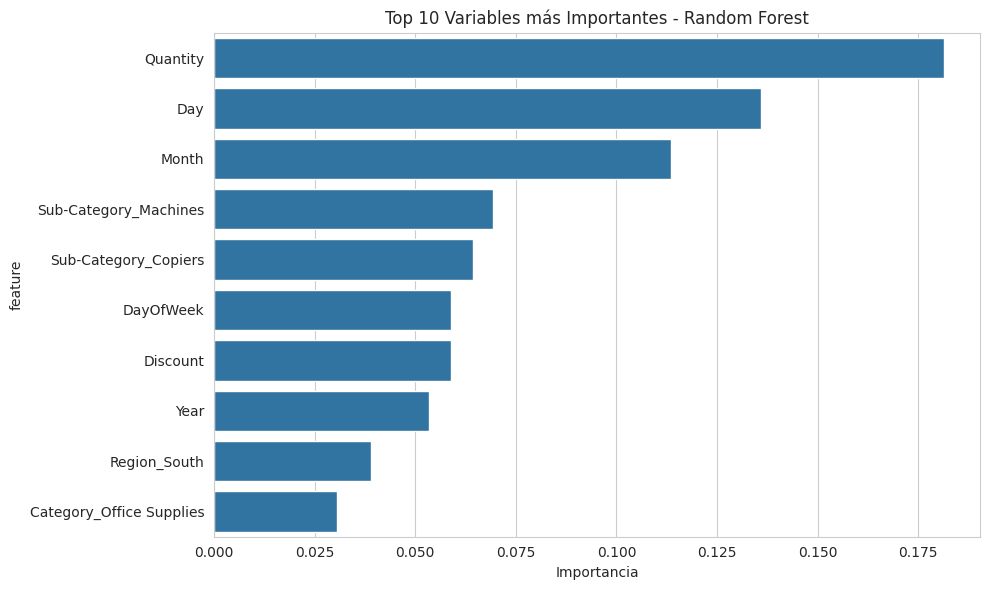

In [32]:
plt.figure(figsize=(10, 6))
top10 = importancia.head(10)
sns.barplot(data=top10, x='importance', y='feature')
plt.title('Top 10 Variables más Importantes - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('feature_importance_parcial.png', dpi=150)
plt.show()

## 9. Gráfico de predicciones vs Reales


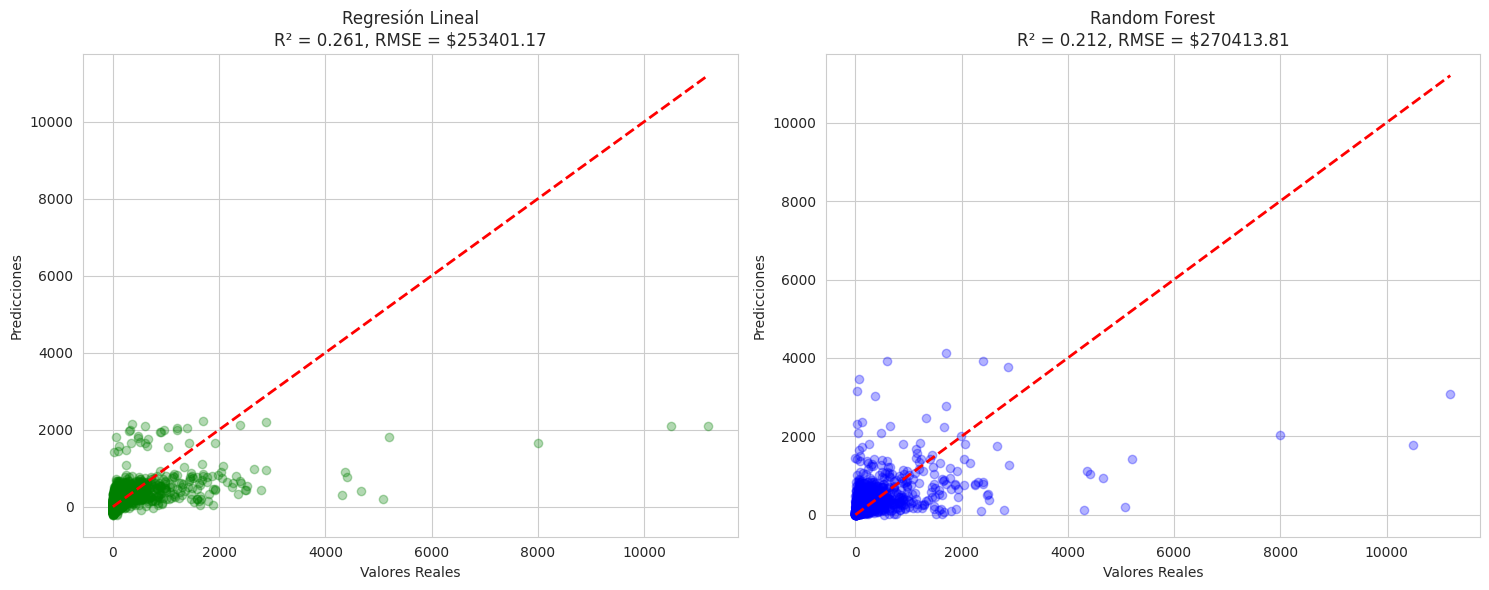

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Regresión Lineal
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, color='green')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Predicciones')
axes[0].set_title(f'Regresión Lineal\nR² = {r2_lr_test:.3f}, RMSE = ${rmse_lr:.2f}')

# Gráfico 2: Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reales')
axes[1].set_ylabel('Predicciones')
axes[1].set_title(f'Random Forest\nR² = {r2_rf_test:.3f}, RMSE = ${rmse_rf:.2f}')

plt.tight_layout()
plt.savefig('comparacion_modelos_parcial.png', dpi=150)
plt.show()